TRAINING + TESTING

This will include:

Loading dataset
Splitting
Scaling
Training models
Confusion matrix
Feature importance

1. Loading Dataset

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

df = pd.read_csv('cleaned.csv')

df.head()

,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,...,Contract_Month-to-Month,Contract_One Year,Contract_Two Year,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check,age_group,avg_monthly_spend,spend_change,high_bill
0,1,37,1,0,34.83,-119.00,2,9,1,42.39,...,False,True,False,False,True,False,Adult,59.33,6.27,0
1,0,46,0,0,34.16,-118.20,0,9,1,10.69,...,True,False,False,False,True,False,Adult,54.24,-50.24,0
2,0,50,0,0,33.65,-117.92,0,4,1,33.65,...,True,False,False,True,False,False,Adult,56.17,17.73,1
3,0,78,1,0,38.01,-122.12,1,13,1,27.82,...,True,False,False,True,False,False,Senior,88.42,9.58,1
4,1,75,1,0,34.23,-119.08,3,3,1,7.38,...,True,False,False,False,True,False,Senior,66.85,17.05,1


In [2]:
df['Customer Status'].unique()

array([0, 1, 2])

2. Train-Test Split

In any supervised machine-learning, we must separate:

Features (X): the information used to make predictions
Target (y): the information we want the model to predict

In [3]:
df = pd.get_dummies(df, drop_first=True) #Initially, One-hot encoding should be applied, else the model will not understand the categorical data.

In [4]:
X = df.drop(['Customer Status'], axis=1) # Input- All columns except target  
y = df['Customer Status']   #output = churn (0/1)

In [5]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2          #80% data- training & 20% data- testing & random_state=42 ensures repeatability
)

3. Feature Scaling (Important for Logistic Regression)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

BALANCING IMBALNCES DATASET

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

MODEL 1 — LOGISTIC REGRESSION

It draws a line (or hyperplane) that best separates two classes.

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

print("\nClassification Report:\n", classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.8459900638750887
[[880  78   2]
 [ 87 260  19]
 [  6  25  52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       960
           1       0.72      0.71      0.71       366
           2       0.71      0.63      0.67        83

    accuracy                           0.85      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.84      0.85      0.84      1409



MODEL 2 — Knn (k nearest neighbours)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_knn))
print(confusion_matrix(y_test, pred_knn))
print("trainscore:", knn.score(X_train, y_train))
print(classification_report(y_test, pred_knn))

Accuracy: 0.7707594038325053
[[842 108  10]
 [125 231  10]
 [ 32  38  13]]
trainscore: 0.8336883209087682
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       960
           1       0.61      0.63      0.62       366
           2       0.39      0.16      0.22        83

    accuracy                           0.77      1409
   macro avg       0.62      0.55      0.57      1409
weighted avg       0.76      0.77      0.76      1409



HYPERPARAMETER TUNING FOR BEST OF K

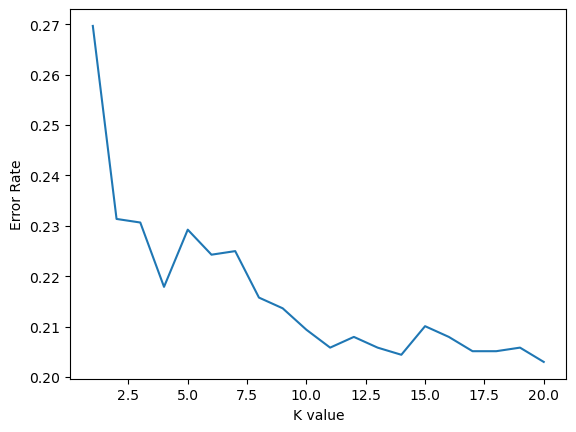

In [10]:
error_rate = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

plt.plot(range(1,21), error_rate)
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
y_pred=knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))


[[842 108  10]
 [125 231  10]
 [ 32  38  13]]


In [13]:
knn.score(X_train, y_train)


0.8336883209087682

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7707594038325053


MODEL 3 - SVM (Support Vector Machine)

Support Vector Machine (SVM) is a supervised machine-learning algorithm used to find the best possible boundary (hyperplane) that separates classes with the maximum margin.

SVM uses support vectors (critical data points near the boundary) to create that line.

In [15]:

# Create SVM model using RBF kernel (most common)
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))
print('svm',svm.score(X_train,y_train))

Accuracy: 0.8388928317955997
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       960
           1       0.72      0.70      0.71       366
           2       0.72      0.40      0.51        83

    accuracy                           0.84      1409
   macro avg       0.78      0.68      0.71      1409
weighted avg       0.83      0.84      0.83      1409

[[894  63   3]
 [101 255  10]
 [ 16  34  33]]
svm 0.8626198083067093


Confusion Matrices (All Models)

A confusion matrix is a table that shows how many:

Correct predictions the model made
Wrong predictions the model made

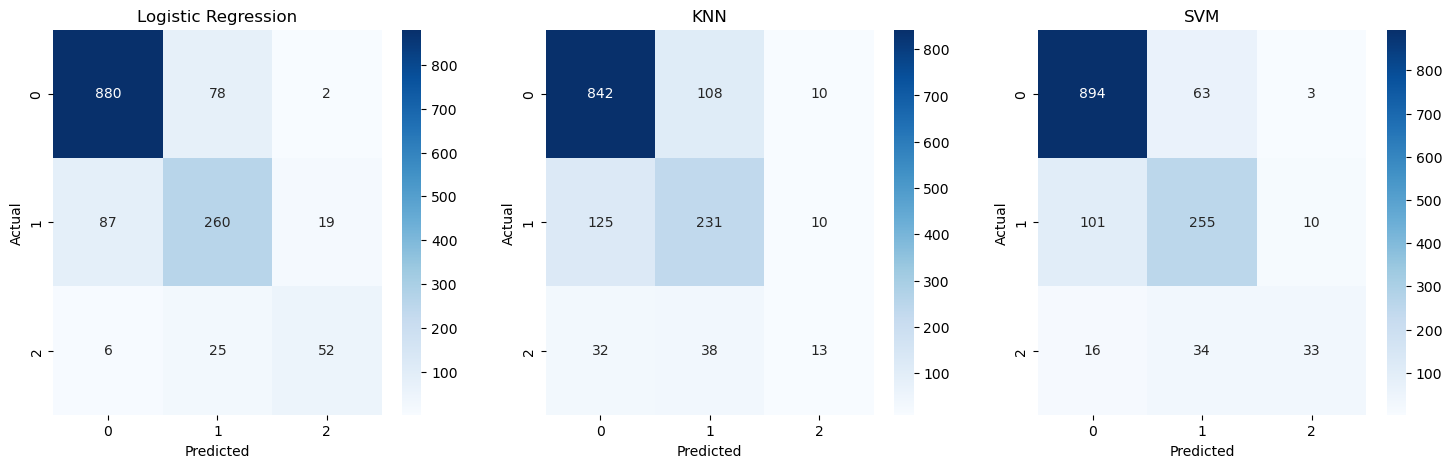

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [pred_lr,y_pred,svm_pred]
titles = ["Logistic Regression", "KNN","SVM"]

for i, model in enumerate(models):
    cm = confusion_matrix(y_test, model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.show()

MODEL 4— DECISION TREE

A model that splits data into branches based on conditions.

In [17]:
dt = DecisionTreeClassifier(criterion="gini", max_depth=5,random_state=42)# Create XGB model
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print("trainscore:", dt.score(X_train, y_train))
print(confusion_matrix(y_test, pred_dt))
print("\nClassification Report:\n", classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.8147622427253371
trainscore: 0.8232161874334398
[[853 107   0]
 [ 94 254  18]
 [  0  42  41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89       960
           1       0.63      0.69      0.66       366
           2       0.69      0.49      0.58        83

    accuracy                           0.81      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.82      0.81      0.82      1409



MODEL 5: Random Forest

A collection of many decision trees → ensemble method.Each tree is trained on different parts of data (bootstrapping).Final prediction = majority vote from all trees.

In [18]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=5)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print("trainscore:", rf.score(X_train, y_train))
print(confusion_matrix(y_test, pred_rf))
print("\nClassification Report:\n", classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.8339247693399574
trainscore: 0.8288959886403976
[[933  27   0]
 [154 199  13]
 [  0  40  43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91       960
           1       0.75      0.54      0.63       366
           2       0.77      0.52      0.62        83

    accuracy                           0.83      1409
   macro avg       0.79      0.68      0.72      1409
weighted avg       0.82      0.83      0.82      1409



MODEL 6 — GRADIENT BOOSTING

Gradient Boosting is a strong ensemble machine-learning model that builds MANY small weak models (usually small decision trees) one after another, and each new model corrects the mistakes of the previous one.

Gradient Boosting = Learn from errors step-by-step.

In [19]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred_gb))
print(confusion_matrix(y_test, pred_gb))
print("trainscore:", gb.score(X_train, y_train))
print("\nClassification Report:\n", classification_report(y_test, pred_gb))

Gradient Boosting Accuracy: 0.8644428672817601
[[908  52   0]
 [ 95 251  20]
 [  0  24  59]]
trainscore: 0.889776357827476

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       960
           1       0.77      0.69      0.72       366
           2       0.75      0.71      0.73        83

    accuracy                           0.86      1409
   macro avg       0.81      0.78      0.79      1409
weighted avg       0.86      0.86      0.86      1409



MODEL 7 - XGB

In [20]:
# Create XGB model
xgb = XGBClassifier(
    n_estimators=200,       # number of trees
    learning_rate=0.05,    # step size
    max_depth=5,           # depth of each tree
    subsample=0.8,         # % of rows used per tree
    colsample_bytree=0.8,  # % of features per tree
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("trainscore:", xgb.score(X_train, y_train))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8644428672817601
[[909  51   0]
 [ 94 250  22]
 [  0  24  59]]
trainscore: 0.9224352147674831

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       960
           1       0.77      0.68      0.72       366
           2       0.73      0.71      0.72        83

    accuracy                           0.86      1409
   macro avg       0.80      0.78      0.79      1409
weighted avg       0.86      0.86      0.86      1409



Final Comparison

In [21]:

results = {
    'Logistic Regression': accuracy_score(y_test, pred_lr),
   'Decision Tree': accuracy_score(y_test, pred_dt),
    'SVM': accuracy_score(y_test, svm_pred),
    'KNN': accuracy_score(y_test, y_pred),
    'Gradient Boosting': accuracy_score(y_test, pred_gb),
    'Random Forest': accuracy_score(y_test, pred_rf),
    'Xgb': accuracy_score(y_test, y_pred),
    

}

pd.DataFrame(results, index=['Accuracy'])

,Logistic Regression,Decision Tree,SVM,KNN,Gradient Boosting,Random Forest,Xgb
Accuracy,0.84599,0.814762,0.838893,0.864443,0.864443,0.833925,0.864443


ABOVE are Best Accuracy Models

In [22]:
import joblib

model = xgb        # or rf, svm, etc.

joblib.dump(model, "telecom_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(X.columns.tolist(), "feature_columns.joblib")

print("Files saved successfully!")


Files saved successfully!


In [23]:
import joblib

feature_columns = joblib.load("feature_columns.joblib")

print(feature_columns)

['Gender', 'Age', 'Married', 'Number of Dependents', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Internet Type_Cable', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year', 'Payment Method_Bank Withdrawal', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'avg_monthly_spend', 'spend_change', 'high_bill', 'age_group_Senior', 'age_group_Young']
